# Fig. 3(b) Reproduction With `bloqade-decoders`

This notebook reproduces the Gemini logical simulator workflow for Fig. 3(b) of `arXiv:2412.15165v1`, while using the decoder implementations from the local `bloqade-decoders` checkout instead of notebook-local decoder code.

What is notebook-local vs decoder-local here:
- The Gemini logical hardware kernels, detector mappings, simulator tasks, tomography, and plotting live in this notebook.
- The MLE decoder is `GurobiDecoder` from the local `bloqade-decoders` repo, using its paper-style logical-gap confidence score.
- The MLD decoder is `TableDecoder` from the local `bloqade-decoders` repo, trained from simulator samples. Its confidence score here is the empirical posterior mass of the selected logical correction for a given detector syndrome.

Notes:
- The paper's exact MLD postselection ranks syndrome patterns by the output fidelity they induce. In this notebook we instead use the decoder-native confidence available from `TableDecoder`'s learned counts.
- The notebook prepends the sibling `../bloqade-decoders/src` path so it uses the current working tree, including the new MLE logical-gap support.
- The default configuration is interactive rather than paper-scale.


In [1]:
import math
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
# import stim

PROJECT_ROOT_CANDIDATES = [Path.cwd(), Path.cwd().parent]
for candidate in PROJECT_ROOT_CANDIDATES:
    candidate = candidate.resolve()
    if (candidate / 'demo' / 'msd_utils').exists():
        sys.path.insert(0, str(candidate))
        break
else:
    raise FileNotFoundError('Could not locate repo root containing demo/msd_utils.')

LOCAL_DECODER_SRC_CANDIDATES = [
    Path.cwd() / '..' / 'bloqade-decoders' / 'src',
    Path.cwd() / 'bloqade-decoders' / 'src',
    Path.cwd().parent / 'bloqade-decoders' / 'src',
    Path.cwd().parent.parent / 'bloqade-decoders' / 'src',
]
for candidate in LOCAL_DECODER_SRC_CANDIDATES:
    candidate = candidate.resolve()
    if candidate.exists():
        sys.path.insert(0, str(candidate))
        break
else:
    raise FileNotFoundError('Could not locate sibling bloqade-decoders/src checkout.')

import bloqade.decoders as bloqade_decoders
from bloqade.decoders import GurobiDecoder, TableDecoder
from bloqade.lanes import GeminiLogicalSimulator
from bloqade.lanes.steane_defaults import steane7_m2dets, steane7_m2obs

from demo.msd_utils.core import (
    BasisDataset,
    DEFAULT_BASIS_LABELS,
    DEFAULT_TARGET_BLOCH,
    bits_to_key,
    fidelity_from_counts,
    key_to_bits,
    logical_expectation,
    pack_boolean_array,
    run_task,
    split_factory_bits,
)
from demo.msd_utils.circuits import (
    build_decoder_kernel_bundle,
    build_injected_decoder_kernel_map,
    build_task_map,
    make_noisy_steane7_initializer,
)
from demo.msd_utils.decoders import (
    build_mld_decoders,
    build_mle_decoders,
    build_shared_mld_postselection_scores,
    compute_dem_data,
    evaluate_curve,
    evaluate_mld_curve,
    injected_baseline,
    make_shape_only_dem,
    matrix_to_dem,
)

print('Using bloqade.decoders from:', Path(bloqade_decoders.__file__).resolve())


Using bloqade.decoders from: /Users/jasonhan/Desktop/qmain/kirin-workspace/bloqade-decoders/src/bloqade/decoders/__init__.py


In [2]:
FAST_CONFIG = {
    'mld_train_shots': 20_000,
    'eval_shots': 4_000,
    'posterior_samples': 20_000,
    'mle_threshold_points': 24,
    'mld_threshold_points': 24,
    # 'batch_size': 10_000,
}

PAPER_SCALE_CONFIG = {
    'mld_train_shots': 1_000_000_000,
    'eval_shots': 250_000,
    'posterior_samples': 200_000,
    'mle_threshold_points': 64,
    'mld_threshold_points': 64,
    # 'batch_size': 50_000,
}

# FAST_CONFIG['posterior_samples'] = 200_000
# FAST_CONFIG['eval_shots'] = 100_000
PAPER_SCALE_CONFIG['mld_train_shots'] = 1_000_000
CONFIG = PAPER_SCALE_CONFIG.copy()

# Magic-state preparation knobs.
#
# The same U3 preparation is used for the injected reference and for each
# encoded magic state fed into the 5-to-1 distillation circuit. To add a
# simple coherent preparation error, edit the *_OFFSET values below.
IDEAL_THETA = 0.3041 * math.pi
IDEAL_PHI = 0.25 * math.pi
IDEAL_LAM = 0.0

# TODO: instead of having theta just be an offset, have an alternative way/more systematic way to inject noise in the circuit.
THETA_OFFSET = 0.30
PHI_OFFSET = 0.0
LAM_OFFSET = 0.0

THETA = IDEAL_THETA + THETA_OFFSET
PHI = IDEAL_PHI + PHI_OFFSET
LAM = IDEAL_LAM + LAM_OFFSET

BASIS_LABELS = DEFAULT_BASIS_LABELS
OUTPUT_QUBIT = 0
ANCILLA_QUBITS = (1, 2, 3, 4)
FACTORY_TARGET = np.array([0, 0, 0, 0], dtype=np.uint8)
# TODO: better understand this MLE_SCORE_MODE ?
MLE_SCORE_MODE = 'best_available'

# This notebook's tomography/sign conventions historically evaluated fidelity
# against the (1, 1, 1) direction after applying notebook-specific sign vectors.
FIDELITY_TARGET_BLOCH = np.ones(3, dtype=np.float64) / np.sqrt(3.0)

def u3_prep_bloch(theta: float, phi: float) -> np.ndarray:
    return np.array([
        math.sin(theta) * math.cos(phi),
        math.sin(theta) * math.sin(phi),
        math.cos(theta),
    ], dtype=np.float64)

PREP_BLOCH = u3_prep_bloch(THETA, PHI)
PREP_FIDELITY = 0.5 + float(np.dot(PREP_BLOCH, FIDELITY_TARGET_BLOCH)) / 2.0

M2DETS_5 = steane7_m2dets(5)
M2OBS_5 = steane7_m2obs(5)
M2DETS_1 = steane7_m2dets(1)
M2OBS_1 = steane7_m2obs(1)

kernel_bundle = build_decoder_kernel_bundle(THETA, PHI, LAM, output_qubit=OUTPUT_QUBIT)
ACTUAL_KERNELS = kernel_bundle.actual
SPECIAL_KERNELS = kernel_bundle.special
INJECTED_KERNELS = kernel_bundle.injected
INJECTED_DECODER_KERNELS = build_injected_decoder_kernel_map()

# _shared_run_task = run_task

# def run_task(task, shots, *, with_noise=True, chunk_size=None):
#     if chunk_size is None:
#         chunk_size = CONFIG['batch_size']
#     return _shared_run_task(
#         task,
#         shots,
#         with_noise=with_noise,
#         chunk_size=chunk_size,
#     )


In [3]:
M2DETS_1

[[1, 0, 0], [1, 1, 0], [1, 1, 1], [1, 0, 1], [0, 1, 1], [0, 1, 0], [0, 0, 1]]

In [4]:
M2OBS_1

[[1], [1], [0], [0], [0], [1], [0]]

In [5]:
M2DETS_5

[[1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
 [1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
 [1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
 [1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
 [0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
 [0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
 [0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
 [0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
 [0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
 [0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0],
 [0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0],
 [0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0],
 [0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
 [0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0],
 [0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0],
 [0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0],
 [0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0, 0],
 [0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0],
 [0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0],
 [0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0],
 [0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0,

In [6]:
M2OBS_5

[[1, 0, 0, 0, 0],
 [1, 0, 0, 0, 0],
 [0, 0, 0, 0, 0],
 [0, 0, 0, 0, 0],
 [0, 0, 0, 0, 0],
 [1, 0, 0, 0, 0],
 [0, 0, 0, 0, 0],
 [0, 1, 0, 0, 0],
 [0, 1, 0, 0, 0],
 [0, 0, 0, 0, 0],
 [0, 0, 0, 0, 0],
 [0, 0, 0, 0, 0],
 [0, 1, 0, 0, 0],
 [0, 0, 0, 0, 0],
 [0, 0, 1, 0, 0],
 [0, 0, 1, 0, 0],
 [0, 0, 0, 0, 0],
 [0, 0, 0, 0, 0],
 [0, 0, 0, 0, 0],
 [0, 0, 1, 0, 0],
 [0, 0, 0, 0, 0],
 [0, 0, 0, 1, 0],
 [0, 0, 0, 1, 0],
 [0, 0, 0, 0, 0],
 [0, 0, 0, 0, 0],
 [0, 0, 0, 0, 0],
 [0, 0, 0, 1, 0],
 [0, 0, 0, 0, 0],
 [0, 0, 0, 0, 1],
 [0, 0, 0, 0, 1],
 [0, 0, 0, 0, 0],
 [0, 0, 0, 0, 0],
 [0, 0, 0, 0, 0],
 [0, 0, 0, 0, 1],
 [0, 0, 0, 0, 0]]

In [7]:
print('Magic-state prep parameters:')
print('  ideal (theta, phi, lam) =', (IDEAL_THETA, IDEAL_PHI, IDEAL_LAM))
print('  offsets                  =', (THETA_OFFSET, PHI_OFFSET, LAM_OFFSET))
print('  actual (theta, phi, lam) =', (THETA, PHI, LAM))
print('  prep Bloch vector        =', tuple(float(x) for x in PREP_BLOCH))
print('  prep fidelity vs target  =', PREP_FIDELITY)


Magic-state prep parameters:
  ideal (theta, phi, lam) = (0.955358325956656, 0.7853981633974483, 0.0)
  offsets                  = (0.3, 0.0, 0.0)
  actual (theta, phi, lam) = (1.255358325956656, 0.7853981633974483, 0.0)
  prep Bloch vector        = (0.6722185482696245, 0.6722185482696243, 0.3102328911069188)
  prep fidelity vs target  = 0.9776620813937549


In [8]:
MLD_SIGN_VECTOR = (1.0, -1.0, 1.0)
# The injected corrected baseline now trains its TableDecoder on the
# deterministic surrogate kernels but still evaluates the physical U3
# injected kernels. That means the final injected fidelity estimate must
# keep the raw injected tomography convention, including the Y-sign flip.
INJECTED_RAW_SIGN_VECTOR = (1.0, -1.0, 1.0)
INJECTED_CORRECTED_SIGN_VECTOR = INJECTED_RAW_SIGN_VECTOR
DEFAULT_SIGN_VECTOR = MLD_SIGN_VECTOR

_shared_fidelity_from_counts = fidelity_from_counts

def fidelity_from_counts(x_bits, y_bits, z_bits, posterior_samples, sign_vector=(1.0, 1.0, 1.0)):
    return _shared_fidelity_from_counts(
        x_bits,
        y_bits,
        z_bits,
        posterior_samples,
        sign_vector=sign_vector,
        target_bloch=FIDELITY_TARGET_BLOCH,
    )


In [9]:
def injected_baseline_raw(task_map, posterior_samples: int):
    return injected_baseline(
        task_map,
        eval_shots=CONFIG['eval_shots'],
        posterior_samples=posterior_samples,
        table_decoder_cls=TableDecoder,
        sign_vector=INJECTED_RAW_SIGN_VECTOR,
        target_bloch=FIDELITY_TARGET_BLOCH,
        raw=True,
        basis_labels=BASIS_LABELS,
    )


In [10]:
sim = GeminiLogicalSimulator()
noisy_steane7_initialize = make_noisy_steane7_initializer(sim)

actual_tasks = build_task_map(
    sim,
    ACTUAL_KERNELS,
    m2dets=M2DETS_5,
    m2obs=M2OBS_5,
    noisy_initializer=noisy_steane7_initialize,
    append_measurements=False,
)
special_tasks = build_task_map(
    sim,
    SPECIAL_KERNELS,
    m2dets=M2DETS_5,
    m2obs=M2OBS_5,
    noisy_initializer=noisy_steane7_initialize,
    append_measurements=False,
)
injected_tasks = build_task_map(
    sim,
    INJECTED_KERNELS,
    m2dets=M2DETS_1,
    m2obs=M2OBS_1,
    noisy_initializer=noisy_steane7_initialize,
    append_measurements=False,
)
injected_decoder_tasks = build_task_map(
    sim,
    INJECTED_DECODER_KERNELS,
    m2dets=M2DETS_1,
    m2obs=M2OBS_1,
    noisy_initializer=noisy_steane7_initialize,
    append_measurements=False,
)

print('Compiled tasks:')
print(' actual:', list(actual_tasks))
print(' special:', list(special_tasks))
print(' injected:', list(injected_tasks))
print(' injected decoder:', list(injected_decoder_tasks))

print('Injected tomography diagnostic (noiseless <labeled basis>):')
for basis, task in injected_tasks.items():
    data = run_task(task, 4000, with_noise=False)
    mean_value = float(np.mean(1.0 - 2.0 * np.asarray(data.observables, dtype=np.float64)[:, 0]))
    print(f'  {basis}: {mean_value:.6f}')

for basis, task in special_tasks.items():
    data = run_task(task, 64, with_noise=False)
    print(basis, 'special-state noiseless observables:', sorted({tuple(row) for row in data.observables}))


Compiled tasks:
 actual: ['X', 'Y', 'Z']
 special: ['X', 'Y', 'Z']
 injected: ['X', 'Y', 'Z']
 injected decoder: ['X', 'Y', 'Z']
Injected tomography diagnostic (noiseless <labeled basis>):
  X: 0.675500
  Y: -0.676000
  Z: 0.300500
X special-state noiseless observables: [(np.uint8(0), np.uint8(0), np.uint8(0), np.uint8(0), np.uint8(0))]
Y special-state noiseless observables: [(np.uint8(0), np.uint8(0), np.uint8(0), np.uint8(0), np.uint8(0))]
Z special-state noiseless observables: [(np.uint8(0), np.uint8(0), np.uint8(0), np.uint8(0), np.uint8(0))]


In [11]:
for basis, task in injected_tasks.items():
    data = run_task(task, 256, with_noise=False)
    print(basis, np.unique(data.observables, axis=0))

X [[0]
 [1]]
Y [[0]
 [1]]
Z [[0]
 [1]]


In [12]:
ACTUAL_KERNELS, SPECIAL_KERNELS, INJECTED_KERNELS

({'X': Method("msd_actual_x"),
  'Y': Method("msd_actual_y"),
  'Z': Method("msd_actual_z")},
 {'X': Method("msd_special_x"),
  'Y': Method("msd_special_y"),
  'Z': Method("msd_special_z")},
 {'X': Method("injected_x"),
  'Y': Method("injected_y"),
  'Z': Method("injected_z")})

In [13]:
injected_tasks["X"].noiseless_tsim_circuit.diagram(height=500)

In [14]:
special_tasks["X"].tsim_circuit.diagram(height=500)

In [15]:
type(special_tasks)

dict

In [16]:
special_tasks

{'X': GeminiLogicalSimulatorTask(logical_squin_kernel=Method("msd_special_x"), noise_model=SimpleNoiseModel(lane_noise=Method("lane_noise"), idle_noise=Method("idle_noise"), cz_unpaired_noise=Method("cz_unpaired_noise"), cz_paired_noise=Method("cz_paired_noise"), global_rz_noise=Method("global_rz_noise"), local_rz_noise=Method("local_rz_noise"), global_r_noise=Method("global_r_noise"), local_r_noise=Method("local_r_noise")), _thread_pool_executor=<concurrent.futures.thread.ThreadPoolExecutor object at 0x12452f2c0>),
 'Y': GeminiLogicalSimulatorTask(logical_squin_kernel=Method("msd_special_y"), noise_model=SimpleNoiseModel(lane_noise=Method("lane_noise"), idle_noise=Method("idle_noise"), cz_unpaired_noise=Method("cz_unpaired_noise"), cz_paired_noise=Method("cz_paired_noise"), global_rz_noise=Method("global_rz_noise"), local_rz_noise=Method("local_rz_noise"), global_r_noise=Method("global_r_noise"), local_r_noise=Method("local_r_noise")), _thread_pool_executor=<concurrent.futures.thread.

In [17]:
x_task_test = special_tasks["X"]

In [18]:
from IPython.display import HTML, display

diagram = x_task_test.tsim_circuit.diagram(height=500)
display(HTML(f"""
<div style="background: white; padding: 12px;">
  {diagram}
</div>
"""))

In [19]:
# x_task_test.run(1, with_noise=False, run_detectors=True)

In [20]:
# x_task_test.run(1, with_noise=True, run_detectors=True)

In [21]:
# result = x_task_test.run(20000, with_noise=False, run_detectors=True)

In [22]:
# det = np.asarray(result.detectors, dtype=np.uint8)

In [23]:
# obs = np.asarray(result.observables, dtype=np.uint8)

In [24]:
# result_noisy = x_task_test.run(20000, with_noise=True, run_detectors=True)

In [25]:
# det_noisy = np.asarray(result_noisy.detectors, dtype=np.uint8)

In [26]:
# obs_noisy = np.asarray(result.observables, dtype=np.uint8)

In [27]:
special_tasks

{'X': GeminiLogicalSimulatorTask(logical_squin_kernel=Method("msd_special_x"), noise_model=SimpleNoiseModel(lane_noise=Method("lane_noise"), idle_noise=Method("idle_noise"), cz_unpaired_noise=Method("cz_unpaired_noise"), cz_paired_noise=Method("cz_paired_noise"), global_rz_noise=Method("global_rz_noise"), local_rz_noise=Method("local_rz_noise"), global_r_noise=Method("global_r_noise"), local_r_noise=Method("local_r_noise")), _thread_pool_executor=<concurrent.futures.thread.ThreadPoolExecutor object at 0x12452f2c0>),
 'Y': GeminiLogicalSimulatorTask(logical_squin_kernel=Method("msd_special_y"), noise_model=SimpleNoiseModel(lane_noise=Method("lane_noise"), idle_noise=Method("idle_noise"), cz_unpaired_noise=Method("cz_unpaired_noise"), cz_paired_noise=Method("cz_paired_noise"), global_rz_noise=Method("global_rz_noise"), local_rz_noise=Method("local_rz_noise"), global_r_noise=Method("global_r_noise"), local_r_noise=Method("local_r_noise")), _thread_pool_executor=<concurrent.futures.thread.

In [28]:
# Conservative cell
# CONFIG['mld_train_shots'] = 5000

In [29]:
def build_mld_decoders_debug(training_dataset: BasisDataset):
    print("det shape/dtype:", training_dataset.detectors.shape, training_dataset.detectors.dtype)
    print("obs shape/dtype:", training_dataset.observables.shape, training_dataset.observables.dtype)

    det = np.ascontiguousarray(training_dataset.detectors, dtype=bool)
    obs = np.ascontiguousarray(training_dataset.observables, dtype=bool)
    print("det contiguous:", det.flags["C_CONTIGUOUS"], det.nbytes)
    print("obs contiguous:", obs.flags["C_CONTIGUOUS"], obs.nbytes)

    anc_det, anc_obs = split_factory_bits(det, obs)
    print("anc det/obs:", anc_det.shape, anc_obs.shape)

    full_dem = make_shape_only_dem(det.shape[1], obs.shape[1])
    factory_dem = make_shape_only_dem(anc_det.shape[1], anc_obs.shape[1])
    print("dem sizes:", full_dem.num_detectors, full_dem.num_observables, factory_dem.num_detectors, factory_dem.num_observables)

    full_shots = np.ascontiguousarray(np.concatenate([det, obs], axis=1), dtype=bool)
    factory_shots = np.ascontiguousarray(np.concatenate([anc_det, anc_obs], axis=1), dtype=bool)
    print("full shots:", full_shots.shape, full_shots.dtype, full_shots.nbytes)
    print("factory shots:", factory_shots.shape, factory_shots.dtype, factory_shots.nbytes)

    print("building full decoder...")
    full_decoder = TableDecoder.from_det_obs_shots(full_dem, full_shots)
    print("built full decoder:", full_decoder.det_obs_counts.shape, full_decoder.det_obs_counts.nbytes)

    print("building factory decoder...")
    factory_decoder = TableDecoder.from_det_obs_shots(factory_dem, factory_shots)
    print("built factory decoder:", factory_decoder.det_obs_counts.shape, factory_decoder.det_obs_counts.nbytes)

    return full_decoder, factory_decoder


In [30]:
# dataset = run_task(special_tasks["X"], 20000, with_noise=True)
# full_decoder, factory_decoder = build_mld_decoders_debug(dataset)

In [31]:
# import time

# task = special_tasks["X"]
# for shots in [100, 1000, 5000, 10000, 100000, 500000, 1000000]:
#     t0 = time.perf_counter()
#     _ = run_task(task, shots, with_noise=True)
#     dt = time.perf_counter() - t0
#     rate = shots / dt
#     print({
#         "shots": shots,
#         "seconds": dt,
#         "shots_per_sec": rate,
#         "hours_for_1b": 1_000_000_000 / rate / 3600,
#     })


In [32]:
injected_tasks["X"].tsim_circuit.diagram(height=500)

In [33]:
injected_summary_raw = injected_baseline_raw(injected_tasks, CONFIG['posterior_samples'])

In [34]:
injected_summary_raw

{'point': 0.9407168638842858,
 'median': 0.9411721355211176,
 'low': 0.9400466963998902,
 'high': 0.9411721355211176,
 'bloch': (0.623624, 0.607896, 0.295168)}

In [35]:
mld_training_data = {}
for basis, task in special_tasks.items():
    print(f"Sampling MLD training data for {basis} with {CONFIG['mld_train_shots']:,} shots...")
    dataset = run_task(task, CONFIG['mld_train_shots'], with_noise=True)
    print("dataset was created")
    mld_training_data[basis] = dataset
    print("cached MLD training data")

mld_ancilla_scores = build_shared_mld_postselection_scores(
    mld_training_data,
    table_decoder_cls=TableDecoder,
    factory_target=FACTORY_TARGET,
    basis_labels=BASIS_LABELS,
    sign_vector=MLD_SIGN_VECTOR,
    target_bloch=FIDELITY_TARGET_BLOCH,
)
mld_training = {
    basis: build_mld_decoders(
        dataset,
        mld_ancilla_scores,
        table_decoder_cls=TableDecoder,
    )
    for basis, dataset in mld_training_data.items()
}
print('built MLD decoders with shared ancilla-pattern fidelity scores')


Sampling MLD training data for X with 1,000,000 shots...
dataset was created
cached MLD training data
Sampling MLD training data for Y with 1,000,000 shots...
dataset was created
cached MLD training data
Sampling MLD training data for Z with 1,000,000 shots...
dataset was created
cached MLD training data
built MLD decoders with shared ancilla-pattern fidelity scores


In [36]:
MLD_SIGN_VECTOR

(1.0, -1.0, 1.0)

In [37]:
# NOTE: this cell requires the gurobipy package to be installed

actual_data = {
    basis: run_task(task, CONFIG['eval_shots'], with_noise=True)
    for basis, task in actual_tasks.items()
}

mle_decoders = {
    basis: build_mle_decoders(
        task,
        gurobi_decoder_cls=GurobiDecoder,
        score_mode=MLE_SCORE_MODE,
    )
    for basis, task in actual_tasks.items()
}

mld_curve = evaluate_mld_curve(
    actual_data,
    mld_training,
    posterior_samples=CONFIG['posterior_samples'],
    factory_target=FACTORY_TARGET,
    sign_vector=MLD_SIGN_VECTOR,
    target_bloch=FIDELITY_TARGET_BLOCH,
    basis_labels=BASIS_LABELS,
)
mle_curve = evaluate_curve(
    actual_data,
    mle_decoders,
    posterior_samples=CONFIG['posterior_samples'],
    threshold_points=CONFIG['mle_threshold_points'],
    metric='MLE logical gap',
    factory_target=FACTORY_TARGET,
    sign_vector=MLD_SIGN_VECTOR,
    target_bloch=FIDELITY_TARGET_BLOCH,
    basis_labels=BASIS_LABELS,
)
injected_summary_corrected = injected_baseline(
    injected_tasks,
    eval_shots=CONFIG['eval_shots'],
    posterior_samples=CONFIG['posterior_samples'],
    table_decoder_cls=TableDecoder,
    sign_vector=INJECTED_CORRECTED_SIGN_VECTOR,
    target_bloch=FIDELITY_TARGET_BLOCH,
    training_task_map=injected_decoder_tasks,
    basis_labels=BASIS_LABELS,
)
injected_summary_raw = injected_baseline_raw(injected_tasks, CONFIG['posterior_samples'])

print('Injected raw baseline fidelity:', injected_summary_raw['point'])
print('Injected corrected baseline fidelity:', injected_summary_corrected['point'])
print('MLE score mode:', next(iter(mle_decoders.values())).factory_score_mode)
print('MLE curve points:', len(mle_curve['accepted_fraction']))
print('MLD curve points:', len(mld_curve['accepted_fraction']))


Restricted license - for non-production use only - expires 2027-11-29
Injected raw baseline fidelity: 0.9411417936824094
Injected corrected baseline fidelity: 0.9611158035952936
MLE score mode: logical_gap
MLE curve points: 36
MLD curve points: 1393


In [38]:
INJECTED_RAW_SIGN_VECTOR, INJECTED_CORRECTED_SIGN_VECTOR

((1.0, -1.0, 1.0), (1.0, -1.0, 1.0))

In [39]:
MLD_SIGN_VECTOR

(1.0, -1.0, 1.0)

In [40]:
FIDELITY_TARGET_BLOCH

array([0.57735027, 0.57735027, 0.57735027])

In [41]:
injected_summary_corrected

{'point': 0.9611158035952936,
 'median': 0.9614300397032096,
 'low': 0.9603046005819823,
 'high': 0.962555478824437,
 'bloch': (0.649888, 0.641584, 0.30588)}

In [42]:
injected_tasks

{'X': GeminiLogicalSimulatorTask(logical_squin_kernel=Method("injected_x"), noise_model=SimpleNoiseModel(lane_noise=Method("lane_noise"), idle_noise=Method("idle_noise"), cz_unpaired_noise=Method("cz_unpaired_noise"), cz_paired_noise=Method("cz_paired_noise"), global_rz_noise=Method("global_rz_noise"), local_rz_noise=Method("local_rz_noise"), global_r_noise=Method("global_r_noise"), local_r_noise=Method("local_r_noise")), _thread_pool_executor=<concurrent.futures.thread.ThreadPoolExecutor object at 0x1246f1790>),
 'Y': GeminiLogicalSimulatorTask(logical_squin_kernel=Method("injected_y"), noise_model=SimpleNoiseModel(lane_noise=Method("lane_noise"), idle_noise=Method("idle_noise"), cz_unpaired_noise=Method("cz_unpaired_noise"), cz_paired_noise=Method("cz_paired_noise"), global_rz_noise=Method("global_rz_noise"), local_rz_noise=Method("local_rz_noise"), global_r_noise=Method("global_r_noise"), local_r_noise=Method("local_r_noise")), _thread_pool_executor=<concurrent.futures.thread.Thread

In [43]:
from IPython.display import HTML, display

diagram = injected_tasks['X'].tsim_circuit.diagram(height=500)
display(HTML(f"""
<div style="background: white; padding: 12px;">
  {diagram}
</div>
"""))

In [44]:
injected_summary_corrected

{'point': 0.9611158035952936,
 'median': 0.9614300397032096,
 'low': 0.9603046005819823,
 'high': 0.962555478824437,
 'bloch': (0.649888, 0.641584, 0.30588)}

In [45]:
len(data.observables[:, 0])

256

In [46]:
for basis, task in injected_tasks.items():
    data = run_task(task, 1000, with_noise=False)
    print(basis, logical_expectation(data.observables[:, 0]))

X 0.664
Y -0.666
Z 0.264


In [47]:
for basis, task in special_tasks.items():
    data = run_task(task, 256, with_noise=False)
    print(basis, np.unique(data.observables, axis=0))

X [[0 0 0 0 0]]
Y [[0 0 0 0 0]]
Z [[0 0 0 0 0]]


In [48]:
for basis, task in special_tasks.items():
    data = run_task(task, 256, with_noise=False)
    print(basis, "output unique:", np.unique(data.observables[:, 0]))
    print(basis, "ancilla unique rows:", np.unique(data.observables[:, 1:], axis=0))

X output unique: [0]
X ancilla unique rows: [[0 0 0 0]]
Y output unique: [0]
Y ancilla unique rows: [[0 0 0 0]]
Z output unique: [0]
Z ancilla unique rows: [[0 0 0 0]]


In [49]:
# fig, ax = plt.subplots(figsize=(7, 5))

# ax.plot(mle_curve['accepted_fraction'], mle_curve['fidelity'], color='tab:blue', label='Distilled (MLE)')
# ax.fill_between(
#     mle_curve['accepted_fraction'],
#     mle_curve['credible'][:, 0],
#     mle_curve['credible'][:, 1],
#     color='tab:blue',
#     alpha=0.15,
# )

# ax.plot(mld_curve['accepted_fraction'], mld_curve['fidelity'], color='tab:orange', label='Distilled (MLD)')
# ax.fill_between(
#     mld_curve['accepted_fraction'],
#     mld_curve['credible'][:, 0],
#     mld_curve['credible'][:, 1],
#     color='tab:orange',
#     alpha=0.15,
# )

# # ax.axhline(injected_summary['point'], color='tab:green', linestyle='-', label='Injected')
# plt.axhline(injected_summary['median'], color='green', label='Injected')
# plt.axhspan(
#     injected_summary['low'],
#     injected_summary['high'],
#     color='green',
#     alpha=0.12,
# )

# ax.fill_between(
#     [0.0, 1.0],
#     injected_summary['low'],
#     injected_summary['high'],
#     color='tab:green',
#     alpha=0.1,
# )

# ax.set_xlabel('Total accepted fraction')
# ax.set_ylabel('Magic state fidelity')
# ax.set_title('Reproduction of Fig. 3(b) with bloqade-decoders on GeminiLogicalSimulator')
# ax.grid(alpha=0.25)
# ax.legend()
# plt.show()


In [50]:
print("Injected summary:", injected_summary_corrected)
print("MLE first few fidelities:", mle_curve['fidelity'][:5])
print("MLD first few fidelities:", mld_curve['fidelity'][:5])


Injected summary: {'point': 0.9611158035952936, 'median': 0.9614300397032096, 'low': 0.9603046005819823, 'high': 0.962555478824437, 'bloch': (0.649888, 0.641584, 0.30588)}
MLE first few fidelities: [0.98844058 0.98281338 0.98281338 0.98168794 0.98168794]
MLD first few fidelities: [0.99294234 0.99294234 0.99294234 0.99294234 0.99294234]


In [51]:
# injected_summary_raw

In [52]:
# injected_summary_corr = injected_baseline(injected_tasks, CONFIG['posterior_samples'])

In [53]:
# injected_summary_corr

In [54]:
injected_summary_raw = injected_baseline_raw(injected_tasks, CONFIG['posterior_samples'])

In [55]:
injected_summary_raw

{'point': 0.9410794398533369,
 'median': 0.9411721355211176,
 'low': 0.9400466963998902,
 'high': 0.9411721355211176,
 'bloch': (0.624032, 0.608544, 0.295368)}

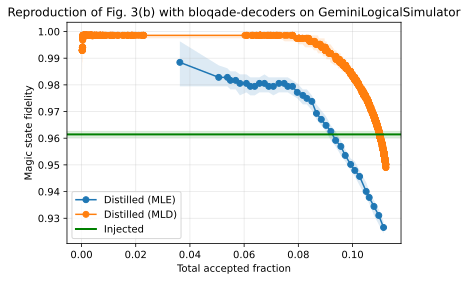

In [56]:
plt.figure(figsize=(6, 4))

plt.plot(
    mle_curve['accepted_fraction'],
    mle_curve['fidelity'],
    marker='o',
    label='Distilled (MLE)',
)
plt.fill_between(
    mle_curve['accepted_fraction'],
    mle_curve['credible'][:, 0],
    mle_curve['credible'][:, 1],
    alpha=0.15,
)

plt.plot(
    mld_curve['accepted_fraction'],
    mld_curve['fidelity'],
    marker='o',
    label='Distilled (MLD)',
)
plt.fill_between(
    mld_curve['accepted_fraction'],
    mld_curve['credible'][:, 0],
    mld_curve['credible'][:, 1],
    alpha=0.15,
)

plt.axhline(
    injected_summary_corrected['median'],
    color='green',
    linewidth=2,
    label='Injected',
)
plt.axhspan(
    injected_summary_corrected['low'],
    injected_summary_corrected['high'],
    color='green',
    alpha=0.12,
)

plt.xlabel('Total accepted fraction')
plt.ylabel('Magic state fidelity')
plt.title('Reproduction of Fig. 3(b) with bloqade-decoders on GeminiLogicalSimulator')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


# Debugging why the plot is bad

In [57]:
def summarize_noiseless(task, shots=256, label=""):
    data = run_task(task, shots, with_noise=False)
    obs = data.observables.astype(np.uint8)
    det = data.detectors.astype(np.uint8)
    print(f"{label} detectors shape:", det.shape)
    print(f"{label} observables shape:", obs.shape)
    print(f"{label} unique detector rows:", len(np.unique(det, axis=0)))
    print(f"{label} unique observable rows:", len(np.unique(obs, axis=0)))
    print(f"{label} output unique:", np.unique(obs[:, 0]))
    print(f"{label} ancilla unique rows:", np.unique(obs[:, 1:], axis=0))
    return data


In [58]:
@gemini_logical.kernel(aggressive_unroll=True)
def dbg_identity_5():
    reg = qubit.qalloc(5)
    return default_post_processing(reg)

dbg_identity_task = build_task(sim, dbg_identity_5, m2dets=None, m2obs=None)
summarize_noiseless(dbg_identity_task, label="identity_5")

NameError: name 'gemini_logical' is not defined

In [ ]:
@gemini_logical.kernel(aggressive_unroll=True)
def dbg_cancel():
    reg = qubit.qalloc(5)
    msd_inverse(reg)
    msd_forward(reg)
    return default_post_processing(reg)

dbg_cancel_task = build_task(sim, dbg_cancel, m2dets=None, m2obs=None)
summarize_noiseless(dbg_cancel_task, label="inverse_then_forward")


inverse_then_forward detectors shape: (256, 15)
inverse_then_forward observables shape: (256, 5)
inverse_then_forward unique detector rows: 1
inverse_then_forward unique observable rows: 1
inverse_then_forward output unique: [0]
inverse_then_forward ancilla unique rows: [[0 0 0 0]]


BasisDataset(detectors=array([[0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       ...,
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]], shape=(256, 15), dtype=uint8), observables=array([[0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0],
       ...,
       [0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0]], shape=(256, 5), dtype=uint8))

In [ ]:
@gemini_logical.kernel(aggressive_unroll=True)
def dbg_tomo_x():
    reg = qubit.qalloc(5)
    tomography_x(reg)
    return default_post_processing(reg)

@gemini_logical.kernel(aggressive_unroll=True)
def dbg_tomo_y():
    reg = qubit.qalloc(5)
    tomography_y(reg)
    return default_post_processing(reg)

@gemini_logical.kernel(aggressive_unroll=True)
def dbg_tomo_z():
    reg = qubit.qalloc(5)
    tomography_z(reg)
    return default_post_processing(reg)

for name, kernel in [("tomo_x", dbg_tomo_x), ("tomo_y", dbg_tomo_y), ("tomo_z", dbg_tomo_z)]:
    task = build_task(sim, kernel, m2dets=None, m2obs=None)
    summarize_noiseless(task, label=name)


tomo_x detectors shape: (256, 15)
tomo_x observables shape: (256, 5)
tomo_x unique detector rows: 1
tomo_x unique observable rows: 2
tomo_x output unique: [0 1]
tomo_x ancilla unique rows: [[0 0 0 0]]
tomo_y detectors shape: (256, 15)
tomo_y observables shape: (256, 5)
tomo_y unique detector rows: 1
tomo_y unique observable rows: 2
tomo_y output unique: [0 1]
tomo_y ancilla unique rows: [[0 0 0 0]]
tomo_z detectors shape: (256, 15)
tomo_z observables shape: (256, 5)
tomo_z unique detector rows: 1
tomo_z unique observable rows: 1
tomo_z output unique: [0]
tomo_z ancilla unique rows: [[0 0 0 0]]


In [ ]:
for name, kernel in [("tomo_x", dbg_tomo_x), ("tomo_y", dbg_tomo_y), ("tomo_z", dbg_tomo_z)]:
    task = build_task(sim, kernel, m2dets=None, m2obs=None)
    summarize_noiseless(task, label=name)


tomo_x detectors shape: (256, 15)
tomo_x observables shape: (256, 5)
tomo_x unique detector rows: 1
tomo_x unique observable rows: 2
tomo_x output unique: [0 1]
tomo_x ancilla unique rows: [[0 0 0 0]]
tomo_y detectors shape: (256, 15)
tomo_y observables shape: (256, 5)
tomo_y unique detector rows: 1
tomo_y unique observable rows: 2
tomo_y output unique: [0 1]
tomo_y ancilla unique rows: [[0 0 0 0]]
tomo_z detectors shape: (256, 15)
tomo_z observables shape: (256, 5)
tomo_z unique detector rows: 1
tomo_z unique observable rows: 1
tomo_z output unique: [0]
tomo_z ancilla unique rows: [[0 0 0 0]]


In [ ]:
@squin.kernel
def tomography_x_inv(reg):
    squin.h(reg[OUTPUT_QUBIT])

@squin.kernel
def tomography_y_inv(reg):
    squin.h(reg[OUTPUT_QUBIT])
    squin.sqrt_z(reg[OUTPUT_QUBIT])

@squin.kernel
def tomography_z_inv(reg):
    return


In [ ]:
@squin.kernel
def prepare_special_x_v2(reg):
    tomography_x_inv(reg)
    msd_inverse(reg)

@squin.kernel
def prepare_special_y_v2(reg):
    tomography_y_inv(reg)
    msd_inverse(reg)

@squin.kernel
def prepare_special_z_v2(reg):
    tomography_z_inv(reg)
    msd_inverse(reg)


In [ ]:
@gemini_logical.kernel(aggressive_unroll=True)
def msd_special_x_v2():
    reg = qubit.qalloc(5)
    prepare_special_x_v2(reg)
    msd_forward(reg)
    tomography_x(reg)
    return default_post_processing(reg)

@gemini_logical.kernel(aggressive_unroll=True)
def msd_special_y_v2():
    reg = qubit.qalloc(5)
    prepare_special_y_v2(reg)
    msd_forward(reg)
    tomography_y(reg)
    return default_post_processing(reg)

@gemini_logical.kernel(aggressive_unroll=True)
def msd_special_z_v2():
    reg = qubit.qalloc(5)
    prepare_special_z_v2(reg)
    msd_forward(reg)
    tomography_z(reg)
    return default_post_processing(reg)

special_v2_tasks = {
    "X": build_task(sim, msd_special_x_v2, m2dets=None, m2obs=None),
    "Y": build_task(sim, msd_special_y_v2, m2dets=None, m2obs=None),
    "Z": build_task(sim, msd_special_z_v2, m2dets=None, m2obs=None),
}

for basis, task in special_v2_tasks.items():
    summarize_noiseless(task, label=f"special_v2_{basis}")


special_v2_X detectors shape: (256, 15)
special_v2_X observables shape: (256, 5)
special_v2_X unique detector rows: 1
special_v2_X unique observable rows: 1
special_v2_X output unique: [0]
special_v2_X ancilla unique rows: [[0 0 0 0]]
special_v2_Y detectors shape: (256, 15)
special_v2_Y observables shape: (256, 5)
special_v2_Y unique detector rows: 1
special_v2_Y unique observable rows: 1
special_v2_Y output unique: [0]
special_v2_Y ancilla unique rows: [[0 0 0 0]]
special_v2_Z detectors shape: (256, 15)
special_v2_Z observables shape: (256, 5)
special_v2_Z unique detector rows: 1
special_v2_Z unique observable rows: 1
special_v2_Z output unique: [0]
special_v2_Z ancilla unique rows: [[0 0 0 0]]


# Additional debug on why plot is bad

In [ ]:
for basis, task in actual_tasks.items():
    data = run_task(task, 256, with_noise=False)
    print(basis, "unique full obs:", np.unique(data.observables, axis=0))
    print(basis, "unique ancilla obs:", np.unique(data.observables[:, 1:], axis=0))


X unique full obs: [[0 0 0 0 0]
 [0 0 0 0 1]
 [0 0 0 1 0]
 [0 0 0 1 1]
 [0 0 1 0 0]
 [0 0 1 0 1]
 [0 0 1 1 0]
 [0 0 1 1 1]
 [0 1 0 0 0]
 [0 1 0 0 1]
 [0 1 0 1 0]
 [0 1 0 1 1]
 [0 1 1 0 0]
 [0 1 1 0 1]
 [0 1 1 1 0]
 [0 1 1 1 1]
 [1 0 0 0 0]
 [1 0 0 0 1]
 [1 0 0 1 0]
 [1 0 0 1 1]
 [1 0 1 0 0]
 [1 0 1 0 1]
 [1 0 1 1 0]
 [1 0 1 1 1]
 [1 1 0 0 0]
 [1 1 0 0 1]
 [1 1 0 1 0]
 [1 1 0 1 1]
 [1 1 1 0 0]
 [1 1 1 0 1]
 [1 1 1 1 0]
 [1 1 1 1 1]]
X unique ancilla obs: [[0 0 0 0]
 [0 0 0 1]
 [0 0 1 0]
 [0 0 1 1]
 [0 1 0 0]
 [0 1 0 1]
 [0 1 1 0]
 [0 1 1 1]
 [1 0 0 0]
 [1 0 0 1]
 [1 0 1 0]
 [1 0 1 1]
 [1 1 0 0]
 [1 1 0 1]
 [1 1 1 0]
 [1 1 1 1]]
Y unique full obs: [[0 0 0 0 0]
 [0 0 0 0 1]
 [0 0 0 1 0]
 [0 0 0 1 1]
 [0 0 1 0 0]
 [0 0 1 0 1]
 [0 0 1 1 0]
 [0 0 1 1 1]
 [0 1 0 0 0]
 [0 1 0 0 1]
 [0 1 0 1 0]
 [0 1 0 1 1]
 [0 1 1 0 1]
 [0 1 1 1 0]
 [1 0 0 0 0]
 [1 0 0 0 1]
 [1 0 0 1 0]
 [1 0 0 1 1]
 [1 0 1 0 0]
 [1 0 1 0 1]
 [1 0 1 1 0]
 [1 0 1 1 1]
 [1 1 0 0 0]
 [1 1 0 0 1]
 [1 1 0 1 0]
 [1 1 0 1 1]
 [1 1 1 

In [ ]:
from collections import Counter

for basis, task in actual_tasks.items():
    data = run_task(task, 5000, with_noise=False)
    anc = data.observables[:, 1:]
    counts = Counter(tuple(map(int, row)) for row in anc)
    print("\n", basis)
    for bitstring, count in counts.most_common(10):
        print(bitstring, count, count / len(anc))



 X
(0, 0, 0, 0) 859 0.1718
(0, 1, 1, 1) 310 0.062
(1, 0, 0, 1) 307 0.0614
(1, 1, 0, 1) 305 0.061
(1, 1, 0, 0) 292 0.0584
(0, 1, 1, 0) 281 0.0562
(0, 0, 1, 0) 278 0.0556
(0, 0, 0, 1) 277 0.0554
(1, 1, 1, 0) 277 0.0554
(1, 0, 1, 0) 270 0.054

 Y
(0, 0, 0, 0) 792 0.1584
(1, 1, 1, 0) 634 0.1268
(0, 0, 1, 0) 393 0.0786
(1, 0, 1, 0) 370 0.074
(0, 1, 0, 0) 335 0.067
(0, 1, 0, 1) 304 0.0608
(1, 1, 0, 1) 276 0.0552
(0, 1, 1, 1) 262 0.0524
(0, 0, 0, 1) 260 0.052
(1, 0, 1, 1) 248 0.0496

 Z
(0, 0, 0, 0) 816 0.1632
(0, 1, 0, 0) 361 0.0722
(1, 0, 0, 1) 342 0.0684
(0, 0, 1, 1) 319 0.0638
(1, 1, 0, 1) 302 0.0604
(0, 1, 1, 1) 287 0.0574
(0, 0, 0, 1) 283 0.0566
(1, 0, 1, 1) 280 0.056
(1, 1, 1, 0) 276 0.0552
(1, 0, 1, 0) 274 0.0548


In [ ]:
def injected_baseline_debug(task_map, posterior_samples: int, shots: int = 4000):
    print("Evaluating injected baseline with SAME data for train and test")
    corrected = {}

    for basis in BASIS_LABELS:
        dataset = run_task(task_map[basis], shots, with_noise=True)

        print(f"\nBasis {basis}")
        print("det shape:", dataset.detectors.shape, "obs shape:", dataset.observables.shape)

        train_det_obs = np.concatenate(
            [dataset.detectors, dataset.observables], axis=1
        ).astype(bool)

        decoder = TableDecoder.from_det_obs_shots(
            make_shape_only_dem(dataset.detectors.shape[1], dataset.observables.shape[1]),
            train_det_obs,
        )

        bits = []
        for det, obs in zip(dataset.detectors, dataset.observables, strict=True):
            flip = np.asarray(decoder.decode(det.astype(bool)), dtype=np.uint8)
            bits.append(int(obs[0] ^ flip[0]))

        bits = np.asarray(bits, dtype=np.uint8)
        corrected[basis] = bits

        print("post-decoding logical mean:", logical_expectation(bits))
        print("logical ones fraction:", float(np.mean(bits)))

    summary = fidelity_from_counts(
        corrected["X"], corrected["Y"], corrected["Z"], posterior_samples, sign_vector=INJECTED_CORRECTED_SIGN_VECTOR
    )
    print("\nLeaky injected summary:", summary)
    return summary


In [ ]:
_ = injected_baseline_debug(injected_tasks, posterior_samples=5000, shots=4000)


Evaluating injected baseline with SAME data for train and test

Basis X
det shape: (4000, 3) obs shape: (4000, 1)
post-decoding logical mean: 0.556
logical ones fraction: 0.222

Basis Y
det shape: (4000, 3) obs shape: (4000, 1)
post-decoding logical mean: 0.5725
logical ones fraction: 0.21375

Basis Z
det shape: (4000, 3) obs shape: (4000, 1)
post-decoding logical mean: 0.572
logical ones fraction: 0.214

Leaky injected summary: {'point': 0.9908920663784793, 'median': 0.9552346034004552, 'low': 0.9551410483069397, 'high': 0.9553281584939706, 'bloch': (0.556, 0.5725, 0.572)}


# Check naive postselection

In [ ]:
def naive_injected_baseline(
    task_map,
    posterior_samples: int,
    shots: int | None = None,
    require_zero_detectors: bool = False,
    min_accepted_per_basis: int = 50,
):
    if shots is None:
        shots = CONFIG["eval_shots"]

    corrected = {}
    accepted_fractions = {}

    for basis in BASIS_LABELS:
        dataset = run_task(task_map[basis], shots, with_noise=True)

        mask = np.ones(len(dataset.observables), dtype=bool)
        if require_zero_detectors:
            mask &= np.all(dataset.detectors == 0, axis=1)

        corrected[basis] = dataset.observables[mask, 0].astype(np.uint8)
        accepted_fractions[basis] = float(np.mean(mask))

    if min(len(corrected[b]) for b in BASIS_LABELS) < min_accepted_per_basis:
        raise RuntimeError("Too few accepted injected shots in at least one basis.")

    summary = fidelity_from_counts(
        corrected["X"],
        corrected["Y"],
        corrected["Z"],
        posterior_samples,
        sign_vector=INJECTED_RAW_SIGN_VECTOR
    )
    summary["accepted_fraction"] = float(np.mean(list(accepted_fractions.values())))
    summary["accepted_fraction_by_basis"] = accepted_fractions
    return summary


def naive_distilled_summary(
    actual_data,
    factory_target,
    posterior_samples: int,
    require_zero_ancilla_detectors: bool = True,
    require_zero_all_detectors: bool = False,
    min_accepted_per_basis: int = 50,
):
    factory_target = np.asarray(factory_target, dtype=np.uint8)

    corrected = {}
    accepted_fractions = {}
    total_kept = 0
    total_shots = 0

    for basis in BASIS_LABELS:
        dataset = actual_data[basis]
        anc_det, anc_obs = split_factory_bits(dataset.detectors, dataset.observables)

        mask = np.all(anc_obs == factory_target, axis=1)

        if require_zero_ancilla_detectors:
            mask &= np.all(anc_det == 0, axis=1)

        if require_zero_all_detectors:
            mask &= np.all(dataset.detectors == 0, axis=1)

        corrected[basis] = dataset.observables[mask, 0].astype(np.uint8)
        accepted_fractions[basis] = float(np.mean(mask))

        total_kept += int(np.sum(mask))
        total_shots += len(mask)

    if min(len(corrected[b]) for b in BASIS_LABELS) < min_accepted_per_basis:
        raise RuntimeError("Too few accepted distilled shots in at least one basis.")

    summary = fidelity_from_counts(
        corrected["X"],
        corrected["Y"],
        corrected["Z"],
        posterior_samples,
        sign_vector=(1.0, -1.0, 1.0)
    )
    summary["accepted_fraction"] = total_kept / total_shots
    summary["accepted_fraction_by_basis"] = accepted_fractions
    summary["factory_target"] = tuple(int(x) for x in factory_target.tolist())
    return summary


def scan_naive_factory_targets(
    actual_data,
    posterior_samples: int,
    require_zero_ancilla_detectors: bool = True,
    require_zero_all_detectors: bool = False,
    min_accepted_per_basis: int = 50,
):
    patterns = sorted(
        {
            tuple(map(int, row))
            for basis in BASIS_LABELS
            for row in actual_data[basis].observables[:, 1:]
        }
    )

    rows = []
    for pattern in patterns:
        try:
            summary = naive_distilled_summary(
                actual_data,
                pattern,
                posterior_samples=posterior_samples,
                require_zero_ancilla_detectors=require_zero_ancilla_detectors,
                require_zero_all_detectors=require_zero_all_detectors,
                min_accepted_per_basis=min_accepted_per_basis,
            )
        except RuntimeError:
            continue

        rows.append(
            {
                "pattern": pattern,
                "accepted_fraction": summary["accepted_fraction"],
                "median": summary["median"],
                "low": summary["low"],
                "high": summary["high"],
                "bloch": summary["bloch"],
            }
        )

    rows.sort(key=lambda row: row["median"], reverse=True)
    return rows


In [ ]:
actual_data = {
    basis: run_task(task, CONFIG["eval_shots"], with_noise=True)
    for basis, task in actual_tasks.items()
}


In [ ]:
inj_raw = naive_injected_baseline(
    injected_tasks,
    posterior_samples=CONFIG["posterior_samples"],
    require_zero_detectors=False,
)
inj_ps = naive_injected_baseline(
    injected_tasks,
    posterior_samples=CONFIG["posterior_samples"],
    require_zero_detectors=True,
)

print("Injected raw:", inj_raw)
print("Injected perfect-stabilizer:", inj_ps)


Injected raw: {'point': 0.9741489085719802, 'median': 0.9704260230235915, 'low': 0.9704210426386828, 'high': 0.9704310034085002, 'bloch': (0.576, 0.533, 0.5335), 'accepted_fraction': 1.0, 'accepted_fraction_by_basis': {'X': 1.0, 'Y': 1.0, 'Z': 1.0}}
Injected perfect-stabilizer: {'point': 1.0009205840668491, 'median': 0.9875185113564718, 'low': 0.9870927532570705, 'high': 0.9879442694558733, 'bloch': (0.5934182590233545, 0.5741969737191399, 0.5676245715792249), 'accepted_fraction': 0.944, 'accepted_fraction_by_basis': {'X': 0.942, 'Y': 0.94175, 'Z': 0.94825}}


In [ ]:
naive_rows = scan_naive_factory_targets(
    actual_data,
    posterior_samples=CONFIG["posterior_samples"],
    require_zero_ancilla_detectors=True,
    require_zero_all_detectors=False,
    min_accepted_per_basis=50,
)

for row in naive_rows[:10]:
    print(row)


{'pattern': (0, 0, 0, 0), 'accepted_fraction': 0.04375, 'median': 0.9817131793333097, 'low': 0.9674312321432712, 'high': 0.9916459752827427, 'bloch': (0.5340909090909091, 0.6949152542372882, 0.6395348837209303)}
{'pattern': (0, 1, 1, 0), 'accepted_fraction': 0.015166666666666667, 'median': 0.9491190811247133, 'low': 0.9062597865935383, 'high': 0.9748811413337901, 'bloch': (0.5666666666666667, 0.46875, 0.6551724137931034)}
{'pattern': (1, 0, 1, 1), 'accepted_fraction': 0.01525, 'median': 0.8912681174694763, 'low': 0.8387219601720576, 'high': 0.9381894419746841, 'bloch': (0.4084507042253521, 0.6140350877192983, 0.38181818181818183)}
{'pattern': (0, 0, 1, 1), 'accepted_fraction': 0.014, 'median': 0.39932180274369916, 'low': 0.3471235701315568, 'high': 0.4583071168590332, 'bloch': (-0.41818181818181815, 0.5925925925925926, -0.5254237288135594)}
{'pattern': (1, 0, 0, 1), 'accepted_fraction': 0.01375, 'median': 0.38111396958289556, 'low': 0.33360856047786436, 'high': 0.44816922492239863, 'bl

In [ ]:
best_pattern = naive_rows[0]["pattern"]
naive_best = naive_distilled_summary(
    actual_data,
    best_pattern,
    posterior_samples=CONFIG["posterior_samples"],
    require_zero_ancilla_detectors=True,
    require_zero_all_detectors=False,
    min_accepted_per_basis=50,
)

print("Best naive distilled summary:", naive_best)


Best naive distilled summary: {'point': 1.0394013382528395, 'median': 0.9817131793333097, 'low': 0.9674312321432712, 'high': 0.9916459752827427, 'bloch': (0.5340909090909091, 0.6949152542372882, 0.6395348837209303), 'accepted_fraction': 0.04375, 'accepted_fraction_by_basis': {'X': 0.044, 'Y': 0.04425, 'Z': 0.043}, 'factory_target': (0, 0, 0, 0)}


In [ ]:
naive_rows_no_flags = scan_naive_factory_targets(
    actual_data,
    posterior_samples=CONFIG["posterior_samples"],
    require_zero_ancilla_detectors=False,
    require_zero_all_detectors=False,
    min_accepted_per_basis=50,
)

for row in naive_rows_no_flags[:10]:
    print(row)


{'pattern': (0, 0, 0, 0), 'accepted_fraction': 0.11175, 'median': 0.944368551182286, 'low': 0.927203088733682, 'high': 0.9688138858782762, 'bloch': (0.45701357466063347, 0.5550660792951542, 0.5550561797752809)}
{'pattern': (0, 1, 1, 0), 'accepted_fraction': 0.059416666666666666, 'median': 0.8094035434138406, 'low': 0.7721516002960754, 'high': 0.8382959857812478, 'bloch': (0.33613445378151263, 0.3939393939393939, 0.32786885245901637)}
{'pattern': (0, 1, 0, 0), 'accepted_fraction': 0.06458333333333334, 'median': 0.7766093773492896, 'low': 0.7432994840542628, 'high': 0.796086594359255, 'bloch': (0.34275618374558303, 0.3524590163934426, 0.25806451612903225)}
{'pattern': (0, 0, 0, 1), 'accepted_fraction': 0.06308333333333334, 'median': 0.7380337843590304, 'low': 0.7112364578397804, 'high': 0.7642865383546738, 'bloch': (0.2788104089219331, 0.22088353413654618, 0.3389121338912134)}
{'pattern': (1, 0, 0, 0), 'accepted_fraction': 0.058583333333333334, 'median': 0.7365898441195489, 'low': 0.7130

In [ ]:
def scan_noiseless_actual_patterns(task_map, shots: int = 10000):
    from collections import Counter, defaultdict

    rows = []
    pattern_output = defaultdict(lambda: {"X": [], "Y": [], "Z": []})
    pattern_counts = Counter()

    for basis in BASIS_LABELS:
        data = run_task(task_map[basis], shots, with_noise=False)
        anc = data.observables[:, 1:]
        out = data.observables[:, 0]
        for a, o in zip(anc, out, strict=True):
            key = tuple(int(x) for x in a)
            pattern_counts[key] += 1
            pattern_output[key][basis].append(int(o))

    total = sum(pattern_counts.values())

    for key, count in pattern_counts.items():
        if min(len(pattern_output[key][b]) for b in BASIS_LABELS) == 0:
            continue
        x_bits = np.asarray(pattern_output[key]["X"], dtype=np.uint8)
        y_bits = np.asarray(pattern_output[key]["Y"], dtype=np.uint8)
        z_bits = np.asarray(pattern_output[key]["Z"], dtype=np.uint8)
        summary = fidelity_from_counts(x_bits, y_bits, z_bits, posterior_samples=5000, sign_vector=(1.0, -1.0, 1.0))
        rows.append({
            "pattern": key,
            "fraction": count / total,
            "median": summary["median"],
            "bloch": summary["bloch"],
        })

    rows.sort(key=lambda row: row["median"], reverse=True)
    return rows

rows_noiseless = scan_noiseless_actual_patterns(actual_tasks, shots=10000)
for row in rows_noiseless[:10]:
    print(row)


{'pattern': (1, 1, 0, 1), 'fraction': 0.05463333333333333, 'median': 0.9908060338274673, 'bloch': (0.6112084063047285, 0.6746987951807228, 0.6035087719298246)}
{'pattern': (0, 0, 0, 0), 'fraction': 0.16296666666666668, 'median': 0.978361991238159, 'bloch': (0.6091954022988506, 0.8580097087378641, 0.6045340050377834)}
{'pattern': (0, 0, 0, 1), 'fraction': 0.053033333333333335, 'median': 0.9724193231971388, 'bloch': (0.5774134790528234, 0.536, 0.6309963099630996)}
{'pattern': (1, 0, 1, 1), 'fraction': 0.05533333333333333, 'median': 0.9303820470897423, 'bloch': (0.5582608695652174, 0.35372848948374763, 0.5444839857651246)}
{'pattern': (0, 1, 1, 0), 'fraction': 0.052, 'median': 0.8726119426250339, 'bloch': (0.5709090909090909, 0.07692307692307693, 0.5731497418244407)}
{'pattern': (0, 1, 0, 0), 'fraction': 0.061766666666666664, 'median': 0.8550840566191722, 'bloch': (0.600739371534196, 0.30074074074074075, 0.28414442700156983)}
{'pattern': (1, 0, 0, 0), 'fraction': 0.0496, 'median': 0.80127

In [ ]:
import itertools
import numpy as np

def clifford_images_of_magic():
    base = np.array([1.0, 1.0, 1.0]) / np.sqrt(3.0)
    images = []
    for perm in itertools.permutations(range(3)):
        for signs in itertools.product([-1, 1], repeat=3):
            vec = np.array([signs[i] * base[perm[i]] for i in range(3)])
            # Keep proper signed permutations from the single-qubit Clifford group
            mat = np.zeros((3, 3), dtype=int)
            for i in range(3):
                mat[i, perm[i]] = signs[i]
            if round(np.linalg.det(mat)) == 1:
                images.append(tuple(np.round(vec, 8)))
    images = sorted(set(images))
    return [np.array(v) for v in images]

def nearest_magic_image(bloch):
    bloch = np.array(bloch, dtype=float)
    candidates = clifford_images_of_magic()
    scored = []
    for cand in candidates:
        scored.append((float(np.dot(bloch, cand)), cand))
    scored.sort(key=lambda x: x[0], reverse=True)
    return scored[:5]

# Example: inspect the suspected accepted branch
bloch = np.array([0.5919335705812574, -0.8640429338103757, 0.5940298507462687])
for score, cand in nearest_magic_image(bloch):
    print("score:", score, "candidate:", cand)


score: 1.1835717226405835 candidate: [ 0.57735027 -0.57735027  0.57735027]
score: 0.5000657090462775 candidate: [-0.57735027 -0.57735027  0.57735027]
score: 0.4976451332077477 candidate: [ 0.57735027 -0.57735027 -0.57735027]
score: 0.1858608803865584 candidate: [0.57735027 0.57735027 0.57735027]
score: -0.1858608803865584 candidate: [-0.57735027 -0.57735027 -0.57735027]


In [ ]:
for basis, task in injected_tasks.items():
    data = run_task(task, 5000, with_noise=False)
    bits = data.observables[:, 0].astype(np.uint8)
    print(basis, logical_expectation(bits))


X 0.5756
Y 0.57
Z 0.5824


In [ ]:
for basis, task in injected_tasks.items():
    data = run_task(task, 5000, with_noise=False)
    bits = data.observables[:, 0].astype(np.uint8)
    print(basis, logical_expectation(bits))


X 0.574
Y 0.5748
Z 0.5768


# Test naive postselection

In [ ]:
def naive_injected_summary(
    task_map,
    posterior_samples: int,
    shots: int | None = None,
    require_zero_detectors: bool = False,
    min_accepted_per_basis: int = 50,
):
    if shots is None:
        shots = CONFIG["eval_shots"]

    corrected = {}
    accepted_fraction_by_basis = {}

    for basis in BASIS_LABELS:
        data = run_task(task_map[basis], shots, with_noise=True)
        mask = np.ones(len(data.observables), dtype=bool)

        if require_zero_detectors:
            mask &= np.all(data.detectors == 0, axis=1)

        corrected[basis] = data.observables[mask, 0].astype(np.uint8)
        accepted_fraction_by_basis[basis] = float(np.mean(mask))

    if min(len(corrected[b]) for b in BASIS_LABELS) < min_accepted_per_basis:
        raise RuntimeError("Too few accepted injected shots.")

    summary = fidelity_from_counts(
        corrected["X"],
        corrected["Y"],
        corrected["Z"],
        posterior_samples,
        sign_vector=INJECTED_RAW_SIGN_VECTOR,
    )
    summary["accepted_fraction"] = float(np.mean(list(accepted_fraction_by_basis.values())))
    summary["accepted_fraction_by_basis"] = accepted_fraction_by_basis
    return summary


In [ ]:
def naive_distilled_summary(
    actual_data,
    factory_target,
    posterior_samples: int,
    require_zero_ancilla_detectors: bool = False,
    require_zero_all_detectors: bool = False,
    min_accepted_per_basis: int = 50,
):
    factory_target = np.asarray(factory_target, dtype=np.uint8)

    corrected = {}
    accepted_fraction_by_basis = {}
    total_kept = 0
    total_shots = 0

    for basis in BASIS_LABELS:
        data = actual_data[basis]
        anc_det, anc_obs = split_factory_bits(data.detectors, data.observables)

        mask = np.all(anc_obs == factory_target, axis=1)

        if require_zero_ancilla_detectors:
            mask &= np.all(anc_det == 0, axis=1)

        if require_zero_all_detectors:
            mask &= np.all(data.detectors == 0, axis=1)

        corrected[basis] = data.observables[mask, 0].astype(np.uint8)
        accepted_fraction_by_basis[basis] = float(np.mean(mask))
        total_kept += int(np.sum(mask))
        total_shots += len(mask)

    if min(len(corrected[b]) for b in BASIS_LABELS) < min_accepted_per_basis:
        raise RuntimeError("Too few accepted distilled shots.")

    summary = fidelity_from_counts(
        corrected["X"],
        corrected["Y"],
        corrected["Z"],
        posterior_samples,
        sign_vector=(1.0, -1.0, 1.0),
    )
    summary["accepted_fraction"] = total_kept / total_shots
    summary["accepted_fraction_by_basis"] = accepted_fraction_by_basis
    summary["factory_target"] = tuple(int(x) for x in factory_target.tolist())
    return summary


In [ ]:
def scan_naive_patterns(
    actual_data,
    posterior_samples: int,
    require_zero_ancilla_detectors: bool = False,
    require_zero_all_detectors: bool = False,
    min_accepted_per_basis: int = 50,
):
    patterns = sorted({
        tuple(map(int, row))
        for basis in BASIS_LABELS
        for row in actual_data[basis].observables[:, 1:]
    })

    rows = []
    for pattern in patterns:
        try:
            s = naive_distilled_summary(
                actual_data,
                pattern,
                posterior_samples=posterior_samples,
                require_zero_ancilla_detectors=require_zero_ancilla_detectors,
                require_zero_all_detectors=require_zero_all_detectors,
                min_accepted_per_basis=min_accepted_per_basis,
            )
        except RuntimeError:
            continue

        rows.append({
            "pattern": pattern,
            "accepted_fraction": s["accepted_fraction"],
            "median": s["median"],
            "low": s["low"],
            "high": s["high"],
            "bloch": s["bloch"],
        })

    rows.sort(key=lambda r: r["median"], reverse=True)
    return rows


In [ ]:
actual_data = {
    basis: run_task(task, CONFIG["eval_shots"], with_noise=True)
    for basis, task in actual_tasks.items()
}

inj_raw = naive_injected_summary(
    injected_tasks,
    posterior_samples=CONFIG["posterior_samples"],
    require_zero_detectors=False,
)

inj_ps = naive_injected_summary(
    injected_tasks,
    posterior_samples=CONFIG["posterior_samples"],
    require_zero_detectors=True,
)

print("Injected raw:", inj_raw)
print("Injected perfect-stabilizer:", inj_ps)


Injected raw: {'point': 0.9747262588411698, 'median': 0.9704263596178496, 'low': 0.9704211495631299, 'high': 0.9704315696725695, 'bloch': (0.5665, 0.5355, 0.5425), 'accepted_fraction': 1.0, 'accepted_fraction_by_basis': {'X': 1.0, 'Y': 1.0, 'Z': 1.0}}
Injected perfect-stabilizer: {'point': 0.9972448260701532, 'median': 0.9875354022747292, 'low': 0.987097238990323, 'high': 0.9879735655591355, 'bloch': (0.5660676532769556, 0.5814323607427055, 0.5750065910888479), 'accepted_fraction': 0.9455833333333334, 'accepted_fraction_by_basis': {'X': 0.946, 'Y': 0.9425, 'Z': 0.94825}}


In [ ]:
rows_no_decoder = scan_naive_patterns(
    actual_data,
    posterior_samples=CONFIG["posterior_samples"],
    require_zero_ancilla_detectors=False,
    require_zero_all_detectors=False,
    min_accepted_per_basis=50,
)

for row in rows_no_decoder[:10]:
    print(row)


{'pattern': (0, 0, 0, 0), 'accepted_fraction': 0.11766666666666667, 'median': 0.8908388158723001, 'low': 0.8730759876555113, 'high': 0.9217434921489279, 'bloch': (0.3922413793103448, 0.48360655737704916, 0.508695652173913)}
{'pattern': (0, 1, 0, 0), 'accepted_fraction': 0.06125, 'median': 0.7643026950256093, 'low': 0.7380422757550135, 'high': 0.8019697490144492, 'bloch': (0.3412698412698413, 0.256198347107438, 0.3278008298755187)}
{'pattern': (1, 0, 0, 0), 'accepted_fraction': 0.058416666666666665, 'median': 0.7636971644244785, 'low': 0.7320294534466029, 'high': 0.8050350460826139, 'bloch': (0.28, 0.36929460580912865, 0.3021276595744681)}
{'pattern': (1, 1, 0, 1), 'accepted_fraction': 0.057833333333333334, 'median': 0.7487829462211736, 'low': 0.7233833212476017, 'high': 0.7874681047922902, 'bloch': (0.30973451327433627, 0.2631578947368421, 0.30833333333333335)}
{'pattern': (0, 0, 0, 1), 'accepted_fraction': 0.06458333333333334, 'median': 0.7350523217303757, 'low': 0.7130043508442669, '

In [ ]:
rows_no_decoder_flagged = scan_naive_patterns(
    actual_data,
    posterior_samples=CONFIG["posterior_samples"],
    require_zero_ancilla_detectors=True,
    require_zero_all_detectors=False,
    min_accepted_per_basis=50,
)

for row in rows_no_decoder_flagged[:10]:
    print(row)


{'pattern': (0, 0, 0, 1), 'accepted_fraction': 0.016083333333333335, 'median': 0.9588369266780795, 'low': 0.9201995851578567, 'high': 0.9793112239320428, 'bloch': (0.46153846153846156, 0.7096774193548387, 0.5949367088607594)}
{'pattern': (0, 0, 0, 0), 'accepted_fraction': 0.042916666666666665, 'median': 0.9553268512368959, 'low': 0.9217013798502305, 'high': 0.9811161020997131, 'bloch': (0.48148148148148145, 0.5647058823529412, 0.5519125683060109)}
{'pattern': (1, 1, 0, 1), 'accepted_fraction': 0.01475, 'median': 0.9064671563340316, 'low': 0.8548014080978614, 'high': 0.9579387949057443, 'bloch': (0.5692307692307692, 0.4117647058823529, 0.47540983606557374)}
{'pattern': (1, 0, 0, 0), 'accepted_fraction': 0.013083333333333334, 'median': 0.8937049110120252, 'low': 0.8326000853576615, 'high': 0.9505201531762592, 'bloch': (0.6, 0.46153846153846156, 0.36)}
{'pattern': (0, 1, 0, 1), 'accepted_fraction': 0.014833333333333334, 'median': 0.44208004293236164, 'low': 0.38618626114770066, 'high': 0.

In [ ]:
best_raw = rows_no_decoder[0]
best_flagged = rows_no_decoder_flagged[0]

print("Best naive raw branch:", best_raw)
print("Best naive flagged branch:", best_flagged)
print("Injected raw median:", inj_raw["median"])
print("Injected perfect-stabilizer median:", inj_ps["median"])


Best naive raw branch: {'pattern': (0, 0, 0, 0), 'accepted_fraction': 0.11766666666666667, 'median': 0.8908388158723001, 'low': 0.8730759876555113, 'high': 0.9217434921489279, 'bloch': (0.3922413793103448, 0.48360655737704916, 0.508695652173913)}
Best naive flagged branch: {'pattern': (0, 0, 0, 1), 'accepted_fraction': 0.016083333333333335, 'median': 0.9588369266780795, 'low': 0.9201995851578567, 'high': 0.9793112239320428, 'bloch': (0.46153846153846156, 0.7096774193548387, 0.5949367088607594)}
Injected raw median: 0.9704263596178496
Injected perfect-stabilizer median: 0.9875354022747292
